<p> <center><img src="https://datascientest.fr/train/assets/logo_datascientest.png" style="height:200px"> </p>

<hr style="border-width:2px;border-color:#75DFC1">
<center><h1> Analyse et prédiction de la variabilité de la production solaire à partir de données ouvertes de la région PACA </h1></center>
<center><h2> Collecte de nouvelles données </h2></center>
<hr style="border-width:2px;border-color:#75DFC1">


Au début du projet, nous avons collecté les données mises à disposition par RTE dans le dataset **éCO2mix** : ces données s'arrétaient en 2024. Depuis, l'année **2025 ainsi que les premiers mois de 2026** sont disponibles. 

Ce notebook propose une collecte des nouvelles données pour les concaténer aux anciennes.

# I - Collecte des données de RTE

On peut trouver les nouvelles données brutes sur le site Internet de **RTE** (https://www.rte-france.com/donnees-publications/eco2mix-donnees-temps-reel/telecharger-indicateurs).

On a préalablement téléchargé ces données et on les a placées dans un répertoire de travail dont on stocke le chemin dans une variable `input_datasets`. Les résultats intermédiaires et finaux seront stockés dans `output_datasets`.

In [43]:
# Répertoire des données d'éCO2mix téléchargées
input_datasets = '../../data/local_data/02_Collecte_datasets/05_annees_2025_2026/input/'

# Répertoire où seront stockés les résultats
output_datasets = '../../data/local_data/02_Collecte_datasets/05_annees_2025_2026/output/'

In [44]:
# Importer des librairies usuelles pour traiter des datasets
import pandas as pd
import numpy as np

# Importer une librairie pour traiter des fichiers zip
from zipfile import ZipFile

On va extraire l'archive téléchargée qui contient les données des années 2025 et début 2026 :

In [45]:
# Récupération du chemin de l'archive à décompresser
chemin_dataset_2025_26 = input_datasets + 'eCO2mix_RTE_PACA_En-cours-TR'

# Décompresser l'archive pour récupérer 
with ZipFile(chemin_dataset_2025_26 + '.zip', 'r') as zip_file :
        zip_file.printdir()
        zip_file.extractall(input_datasets)
        

File Name                                             Modified             Size
eCO2mix_RTE_PACA_En-cours-TR.xls               2026-02-19 13:21:32      9091679


In [46]:
# Observer les premières lignes du dataset le plus ancien (correspond à l'année 2013) :
print("\nJeu de données 2025-2026 :")

## Lire le jeu de données
df = pd.read_csv(chemin_dataset_2025_26 + '.xls', sep='\t', encoding='latin_1')

## Afficher les premières lignes
display(df.head())

## Afficher les dernières lignes
display(df.tail())

## Afficher la taille du dataset
print(f"Nombre de colonnes du jeu de données 2025-2026 : {df.shape[1]}.")



Jeu de données 2025-2026 :


/tmp/ipykernel_13355/2637088666.py:5: DtypeWarning: Columns (17,26,29,38,44,51,55,57,59,61,63,65) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(chemin_dataset_2025_26 + '.xls', sep='\t', encoding='latin_1')


,Périmètre,Nature,Date,Heures,Consommation,Thermique,Nucléaire,Eolien,Solaire,Hydraulique,...,TCH Nucléaire (%),TCO Eolien (%),TCH Eolien (%),TCO Solaire (%),TCH Solaire (%),TCO Hydraulique (%),TCH Hydraulique (%),TCO Bioénergies (%),TCH Bioénergies (%),Unnamed: 67
0,PACA,Données temps réel,2025-01-01,00:00,5583.0,634.0,0.0,1.0,0.0,571.0,...,ND,0.02,1.04,0.0,0.0,10.23,17.68,1.45,27.27,NaN
1,PACA,Données temps réel,2025-01-01,00:15,5532.0,453.0,0.0,1.0,0.0,721.0,...,ND,0.02,1.04,0.0,0.0,13.03,22.33,1.45,26.94,NaN
2,PACA,Données temps réel,2025-01-01,00:30,5430.0,390.0,0.0,2.0,0.0,717.0,...,ND,0.04,2.08,0.0,0.0,13.2,22.21,1.47,26.94,NaN
3,PACA,Données temps réel,2025-01-01,00:45,5321.0,391.0,0.0,1.0,0.0,721.0,...,ND,0.02,1.04,0.0,0.0,13.55,22.33,1.47,26.26,NaN
4,PACA,Données temps réel,2025-01-01,01:00,5277.0,206.0,0.0,2.0,0.0,720.0,...,ND,0.04,2.08,0.0,0.0,13.64,22.30,1.48,26.26,NaN


,Périmètre,Nature,Date,Heures,Consommation,Thermique,Nucléaire,Eolien,Solaire,Hydraulique,...,TCH Nucléaire (%),TCO Eolien (%),TCH Eolien (%),TCO Solaire (%),TCH Solaire (%),TCO Hydraulique (%),TCH Hydraulique (%),TCO Bioénergies (%),TCH Bioénergies (%),Unnamed: 67
39836,PACA,Données temps réel,2026-02-19,23:00,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
39837,PACA,Données temps réel,2026-02-19,23:15,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
39838,PACA,Données temps réel,2026-02-19,23:30,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
39839,PACA,Données temps réel,2026-02-19,23:45,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
39840,RTE ne pourra Ãªtre tenu responsable de l'usag...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


Nombre de colonnes du jeu de données 2025-2026 : 68.


On remarque que ce nouveau dataset présente des mesures toutes les 15 minutes alors que dans nos précédents jeux de données d'éCO2mix les mesures n'avaient lieu que toutes les 30 minutes. Pour conserver la cohérence entre l'ancien et le nouveau jeu de donnée, on va devoir supprimer une mesure sur deux.

Concernant l'année 2026, on remarque que les dernières lignes concernant le jour où les données ont été téléchargées sont manquantes : des lignes ont été créées pour cette journée jusqu'à minuit, mais les dernières sont dans le futur par rapport à l'heure d'extraction, d'où les valeurs manquantes observées.

On va :
- ne garder que les colonnes que nous avions conservées dans le premier jeu de données ;
- supprimer les observations où la variable `TCH Solaire (%)` est absente (ce qui nous permet d'éliminer les observations dans le futur par rapport à l'extraction ainsi que la dernière ligne qui est un disclaimer) ;
- supprimer une ligne sur deux pour avoir la même résolution temporelle que dans le premier jeu de données. 
- vérifier que le fuseau horaire est le fuseau de France Métropolitaine (comme les anciens datasets)
- convertir le cas échéant au fuseau UTC et traiter les données manquantes ou en double à cause des changements d'heures


## A - Sélection des colonnes

In [47]:
# Liste des variables d'éCO2mix retenues dans l'ancien dataset
variables_retenues = ['Périmètre', 'Nature', 'Date', 'Heures', 
                      'Consommation', 'Solaire', 'Ech. physiques', 
                      'Stockage batterie', 'Déstockage batterie', 
                      'TCO Solaire (%)', 'TCH Solaire (%)']

# Vérification de la présence de ces variables dans le nouveau dataset
toutes_presentes = True
for var in variables_retenues :
    if var not in df.columns :
        toutes_presentes = False

print("Les variables précédemment retenues sont-elles toutes présentes dans le nouveau dataset ?", toutes_presentes)


Les variables précédemment retenues sont-elles toutes présentes dans le nouveau dataset ? True


In [48]:
# Les variables étant toutes présentes, on peut procéder à leur extraction
print("Dimensions du dataset avant réduction du nombre de variables :", df.shape)
df = df[variables_retenues]
print("Dimensions du dataset après réduction du nombre de variables :", df.shape)

Dimensions du dataset avant réduction du nombre de variables : (39841, 68)
Dimensions du dataset après réduction du nombre de variables : (39841, 11)


## B - Suppression des observations inutiles

Les observations ne contenant pas la variable `TCH Solaire (%)` ne permettront pas de calculer la variable cible de variation de production : on les retire du dataset.

In [49]:
# On supprime les lignes où la variable TCH Solaire est manquante
df = df.dropna(subset=['TCH Solaire (%)'])

On vérifie s'il reste des valeurs manquantes :

In [50]:
print(df.isna().sum())

Périmètre              0
Nature                 0
Date                   0
Heures                 0
Consommation           0
Solaire                0
Ech. physiques         0
Stockage batterie      0
Déstockage batterie    0
TCO Solaire (%)        0
TCH Solaire (%)        0
dtype: int64


## C - Résolution temporelle

On supprime une observation sur deux pour conserver la même résolution temporelle que précédemment.

In [51]:
display(df.head())

,Périmètre,Nature,Date,Heures,Consommation,Solaire,Ech. physiques,Stockage batterie,Déstockage batterie,TCO Solaire (%),TCH Solaire (%)
0,PACA,Données temps réel,2025-01-01,00:00,5583.0,0.0,4293.0,0.0,0.0,0.0,0.0
1,PACA,Données temps réel,2025-01-01,00:15,5532.0,0.0,4324.0,0.0,0.0,0.0,0.0
2,PACA,Données temps réel,2025-01-01,00:30,5430.0,0.0,4290.0,0.0,0.0,0.0,0.0
3,PACA,Données temps réel,2025-01-01,00:45,5321.0,0.0,4180.0,0.0,0.0,0.0,0.0
4,PACA,Données temps réel,2025-01-01,01:00,5277.0,0.0,4321.0,0.0,0.0,0.0,0.0


In [52]:
# Les heures qu'on souhaite conserver se terminent par le caractère '0' (les autres par '5')
print("Dimensions du dataset avant suppression des lignes :", df.shape)
df = df.loc[df['Heures'].str.endswith('0')]
print("Dimensions du dataset après suppression des lignes :", df.shape)
display(df.tail())

Dimensions du dataset avant suppression des lignes : (39802, 11)
Dimensions du dataset après suppression des lignes : (19901, 11)


,Périmètre,Nature,Date,Heures,Consommation,Solaire,Ech. physiques,Stockage batterie,Déstockage batterie,TCO Solaire (%),TCH Solaire (%)
39792,PACA,Données temps réel,2026-02-19,12:00,5181.0,678.0,3030.0,0.0,0.0,13.09,24.08
39794,PACA,Données temps réel,2026-02-19,12:30,5211.0,825.0,2917.0,0.0,0.0,15.83,29.30
39796,PACA,Données temps réel,2026-02-19,13:00,5152.0,842.0,2854.0,0.0,0.0,16.34,29.90
39798,PACA,Données temps réel,2026-02-19,13:30,5177.0,909.0,2833.0,0.0,0.0,17.56,32.28
39800,PACA,Données temps réel,2026-02-19,14:00,5060.0,726.0,2884.0,0.0,0.0,14.35,25.78


## D - Fuseau horaire

RTE ne précise pas le fuseau horaire utilisé pour le dataset. Si le fuseau est le fuseau de France métropolitaine, on observera un décalage d'une heure en plus ou en moins entre le jour avant et suivant un changement d'heure.

Changements d'heure en 2025 :
 - passage à l'heure d'été : entre le 29 et le 30 mars
 - passage à l'heure d'hiver : entre le 25 et le 26 octobre

Changements d'heure en 2026 (dans le futur par rapport à la dernière extraction donc non traitée pour le moment) :
 - passage à l'heure d'été : entre le 28 et le 29 mars
 - passage à l'heure d'hiver : entre le 24 et le 25 octobre


In [53]:
# On importe une librairie de Datavizualisation
import matplotlib.pyplot as plt
%matplotlib inline

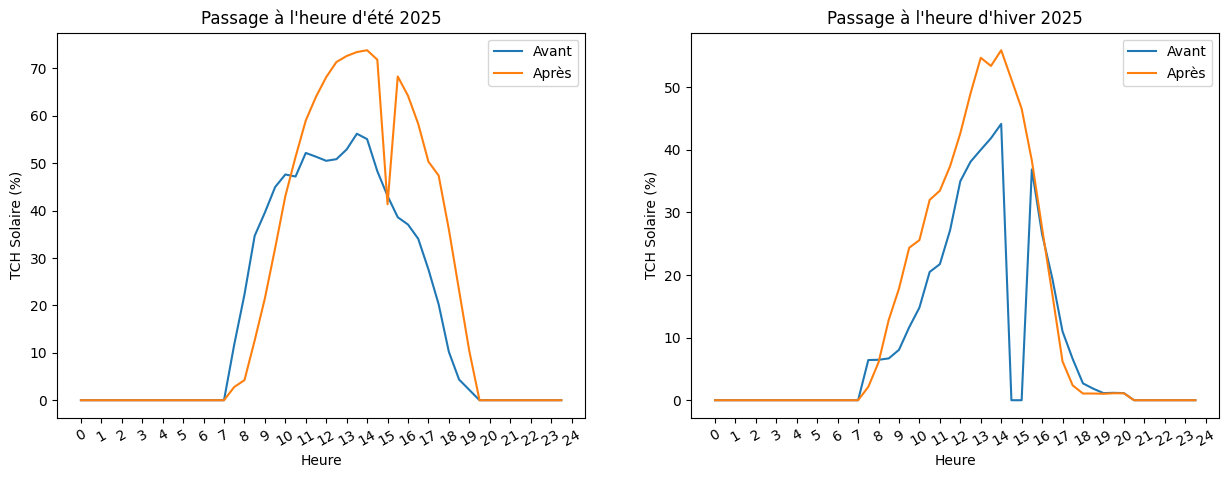

In [54]:
plt.figure(figsize=(15,5))

# On affiche la production d'énergie solaire avant et après le passage à l'heure d'été
plt.subplot(121)
plt.plot(df[df['Date'] == '2025-03-29'].Heures, df[df['Date'] == '2025-03-29']['TCH Solaire (%)'], label='Avant')
plt.plot(df[df['Date'] == '2025-03-30'].Heures, df[df['Date'] == '2025-03-30']['TCH Solaire (%)'], label='Après')
plt.xlabel('Heure')
plt.ylabel('TCH Solaire (%)')
# On nettoie les ticks sur l'axe des x car sinon on ne peut rien lire
# On n'affiche que les heures
plt.xticks([2*k for k in range(0, 25)],
          [str(k) for k in range(25)],
          rotation=30)
plt.title("Passage à l'heure d'été 2025")
plt.legend()

# On affiche la production d'énergie solaire avant et après le passage à l'heure d'hiver
plt.subplot(122)
plt.plot(df[df['Date'] == '2025-10-25'].Heures, df[df['Date'] == '2025-10-25']['TCH Solaire (%)'], label='Avant')
plt.plot(df[df['Date'] == '2025-10-26'].Heures, df[df['Date'] == '2025-10-26']['TCH Solaire (%)'], label='Après');
plt.xlabel('Heure')
plt.ylabel('TCH Solaire (%)')
# On nettoie les ticks sur l'axe des x car sinon on ne peut rien lire
# On n'affiche que les heures
plt.xticks([2*k for k in range(0, 25)],
          [str(k) for k in range(25)],
          rotation=30)
plt.title("Passage à l'heure d'hiver 2025")
plt.legend();

On observe bien un changement d'heure : on va convertir notre fuseau horaire au fuseau international UTC pour concaténer nos données avec d'autres sources.

## E - Conversion du fuseau horaire en UTC

Nous venons de voir que nos données de production étaient données en fonction du fuseau horaire de France métropolitaine.

Il y a deux raisons pour lesquelles nous devrions **changer de fuseau horaire** :    
 - Premièrement le fuseau horaire actuel introduit une modification du *décalage entre l'heure solaire et l'heure légale* deux fois par an : cela **risque de perturber** notre modélisation ;

 - Deuxièmement nous allons devoir *aggréger de nouvelles variables explicatives* à notre jeu de données pour pouvoir expliquer notre variable cible. Comme nous interrogerons des **bases internationnales**, il nous faut convertir nos dates et heures en UTC.

On va créer une nouvelle variable `datetime_utc` qui contiendra les mêmes informations que les variables `Date` et `Heures`, mais en heures UTC, de manière à pouvoir aggréger plus facilement d'autres données par la suite, sur la base de cette variable.

In [55]:
# Aggréger la date et l'heure FR dans une nouvelle colonne
df['datetime_fr'] = pd.to_datetime(df['Date'] + ' ' + df['Heures'], format="%Y-%m-%d %H:%M")

# Indiquer que l'heure est celle de Paris
df['datetime_fr'] = df['datetime_fr'].dt.tz_localize("Europe/Paris",
                                                     nonexistent='shift_forward',
                                                     ambiguous=True)
# Convertir en UTC
df['datetime_utc'] = df['datetime_fr'].dt.tz_convert("UTC")


Comme vu pour l'extraction initiale des données, il faut traiter les doublons créés lors du passage à l'heure d'été.

In [56]:
# Voir les duplicatas au moment du passage à l'heure d'été
display(df[df.duplicated(subset=['datetime_utc'])]) # Tous les dulicatas correspondent à des passages à l'heure d'été
print("Nombre de duplicata :", df.duplicated(subset=['datetime_utc']).sum())


,Périmètre,Nature,Date,Heures,Consommation,Solaire,Ech. physiques,Stockage batterie,Déstockage batterie,TCO Solaire (%),TCH Solaire (%),datetime_fr,datetime_utc
8458,PACA,Données temps réel,2025-03-30,02:30,4199.0,0.0,2757.0,0.0,0.0,0.0,0.0,2025-03-30 03:00:00+02:00,2025-03-30 01:00:00+00:00
8460,PACA,Données temps réel,2025-03-30,03:00,4142.0,0.0,2688.0,0.0,0.0,0.0,0.0,2025-03-30 03:00:00+02:00,2025-03-30 01:00:00+00:00


Nombre de duplicata : 2


In [57]:
# On supprime les duplicatas
df = df.drop_duplicates(subset=['datetime_utc'])
print("Nombre de duplicata restants :", df.duplicated(subset=['datetime_utc']).sum())


Nombre de duplicata restants : 0


Inversement, le passage à l'heure d'hiver crée des données manquantes qu'il nous faut reconstituer.

In [58]:
# Recherche des créneaux manquants

# On commence par faire la liste des créneaux qui devraient être présents dans le jeu de données
# Un créneau toute les 30 minutes entre le premier et le dernier créneau horaire du dataset
totalite_creneaux = pd.date_range(start=df['datetime_utc'].iloc[0], end=df['datetime_utc'].iloc[-1], freq='30min')

# Créneaux manquants
print("Créneaux manquants :")
creneaux_manquants = totalite_creneaux.difference(df['datetime_utc'])
print(creneaux_manquants) # Les seuls créneaux manquants correspondent au passage à l'heure d'hiver


Créneaux manquants :
DatetimeIndex(['2025-10-26 01:00:00+00:00', '2025-10-26 01:30:00+00:00'], dtype='datetime64[ns, UTC]', freq='30min')


Les **seuls créneaux manquants** sont ceux dûs aux **passages à l'heure d'hiver**.

On décide de traiter ces créneaux manquants *de la même manière* que ceux de l'heure inexistante au moment du passage à l'heure d'été, c'est à dire qu'on **copie les données de l'heure suivante**.

L'**impact** de ces données synthétique pour notre problématique de production d'énergie solaire est **minime** vu que les changement d'heure ont lieu à un moment où *les panneaux solaires ne produisent pas* d'énergie.

In [59]:
print(df.shape)
df2 = pd.DataFrame(totalite_creneaux, columns=['datetime_utc'])
df = df2.merge(df, how='left', on='datetime_utc')
print(df.shape)
print(f"\n{df.isna().sum()}")
df.sort_values(by='datetime_utc', inplace=True)

for creneau in creneaux_manquants:
    df.loc[df['datetime_utc']== creneau, 'Périmètre':'datetime_fr'] = df.loc[df['datetime_utc'] == creneau + pd.Timedelta(hours=1), 'Périmètre':'datetime_fr'].values

print(f"\n{df.isna().sum()}")


(19899, 13)
(19901, 13)

datetime_utc           0
Périmètre              2
Nature                 2
Date                   2
Heures                 2
Consommation           2
Solaire                2
Ech. physiques         2
Stockage batterie      2
Déstockage batterie    2
TCO Solaire (%)        2
TCH Solaire (%)        2
datetime_fr            2
dtype: int64

datetime_utc           0
Périmètre              0
Nature                 0
Date                   0
Heures                 0
Consommation           0
Solaire                0
Ech. physiques         0
Stockage batterie      0
Déstockage batterie    0
TCO Solaire (%)        0
TCH Solaire (%)        0
datetime_fr            0
dtype: int64


On abandonne maintenant les colonnes de dates inutiles pour ne conserver que le **fuseau horaire UTC** :

In [60]:
# On supprime les colonnes 'Date', 'Heures' et 'datetime_fr'
df = df.drop(['Date', 'Heures', 'datetime_fr'], axis=1)


Enfin, on réinitialise l'index :

In [61]:
# On réinitialise l'index
df.reset_index(drop=True, inplace=True)

display(df.head())
print(df.shape)

,datetime_utc,Périmètre,Nature,Consommation,Solaire,Ech. physiques,Stockage batterie,Déstockage batterie,TCO Solaire (%),TCH Solaire (%)
0,2024-12-31 23:00:00+00:00,PACA,Données temps réel,5583.0,0.0,4293.0,0.0,0.0,0.0,0.0
1,2024-12-31 23:30:00+00:00,PACA,Données temps réel,5430.0,0.0,4290.0,0.0,0.0,0.0,0.0
2,2025-01-01 00:00:00+00:00,PACA,Données temps réel,5277.0,0.0,4321.0,0.0,0.0,0.0,0.0
3,2025-01-01 00:30:00+00:00,PACA,Données temps réel,5314.0,0.0,4380.0,0.0,0.0,0.0,0.0
4,2025-01-01 01:00:00+00:00,PACA,Données temps réel,5262.0,0.0,4452.0,0.0,0.0,0.0,0.0


(19901, 10)


In [62]:
print("Valeurs prises par 'Stockage batterie' :", df['Stockage batterie'].unique(), '\n')
print("Valeurs prises par 'Déstockage batterie' :", df['Déstockage batterie'].unique())

Valeurs prises par 'Stockage batterie' : [  0.  -1.  -3.  -7.  -2.  -4.  -5.  -6. -10.  -8.] 

Valeurs prises par 'Déstockage batterie' : [0. 1. 3. 2.]


## F - Enregistrement

On enregistre le résultat obtenu à cette étape avant de poursuivre la collecte de données.

In [63]:
# On enregistre une seconde version de ce dataset production avant ajout d'autres variables
df.to_csv(output_datasets + "production_2025_2025.csv", index=False)

# II - Collecte des données astronomiques

On va maintenant collecter les données astronomiques pour les 5 lieux significatifs retenus pour le projet.

In [64]:
# Récupération des coordonnées des cinq points significatifs que l'on a précédemment déterminé.
df_communes = pd.read_csv('../../data/local_data/01_Clustering/output/best_communes_geo_energy.csv')
display(df_communes.head())
print(df_communes.dtypes)

,cluster_geo,best_commune,code_insee,lat,lon,energie_totale,poids,prefix
0,2,Cruis,4065,44.0845,5.8397,20356525.0,0.22,CRU
1,4,Saint-Étienne-le-Laus,5140,44.5075,6.1616,325158.0,0.06,SEL
2,0,Saint-Vallier-de-Thiey,6130,43.6994,6.8516,344281.0,0.07,SVT
3,1,Bras,83021,43.4723,5.9558,10603661.0,0.29,BRA
4,3,Eygalières,13034,43.7638,4.9554,1510927.0,0.36,EYG


cluster_geo         int64
best_commune       object
code_insee          int64
lat               float64
lon               float64
energie_totale    float64
poids             float64
prefix             object
dtype: object


In [65]:
# On importe les librairies dont on a besoin
from pysolar.solar import *
import datetime

In [66]:
# Attention, l'exécution de cette cellule est longue !
# On parcours les villes
for ville in df_communes['prefix'] :
    print(ville + "...")
    latitude = df_communes.loc[df_communes['prefix']==ville, 'lat'].iloc[0]
    longitude = df_communes.loc[df_communes['prefix']==ville, 'lon'].iloc[0]

    # On crée une nouvelle colonne pour la ville pour l'azimuth
    print("\tAzimuth...")
    df[ville + '_azimuth'] = df['datetime_utc'].apply(lambda date : get_azimuth(latitude, longitude, date))
    print("\t\tOK")

    # On crée une nouvelle colonne pour la ville pour l'altitude
    print("\tAltitude...")
    df[ville + '_altitude'] = df['datetime_utc'].apply(lambda date : get_altitude(latitude, longitude, date))
    print("\t\tOK")

    print(ville + "-> OK\n")

CRU...
	Azimuth...
		OK
	Altitude...
		OK
CRU-> OK

SEL...
	Azimuth...
		OK
	Altitude...
		OK
SEL-> OK

SVT...
	Azimuth...
		OK
	Altitude...
		OK
SVT-> OK

BRA...
	Azimuth...
		OK
	Altitude...
		OK
BRA-> OK

EYG...
	Azimuth...
		OK
	Altitude...
		OK
EYG-> OK



In [67]:
display(df.head(10))

,datetime_utc,Périmètre,Nature,Consommation,Solaire,Ech. physiques,Stockage batterie,Déstockage batterie,TCO Solaire (%),TCH Solaire (%),CRU_azimuth,CRU_altitude,SEL_azimuth,SEL_altitude,SVT_azimuth,SVT_altitude,BRA_azimuth,BRA_altitude,EYG_azimuth,EYG_altitude
0,2024-12-31 23:00:00+00:00,PACA,Données temps réel,5583.0,0.0,4293.0,0.0,0.0,0.0,0.0,335.434321,-67.369464,336.570106,-67.076724,337.389091,-68.014208,335.076231,-67.960536,333.110045,-67.381887
1,2024-12-31 23:30:00+00:00,PACA,Données temps réel,5430.0,0.0,4290.0,0.0,0.0,0.0,0.0,353.592974,-68.815418,354.514923,-68.418560,356.100223,-69.264502,353.714311,-69.433122,351.230655,-69.049223
2,2025-01-01 00:00:00+00:00,PACA,Données temps réel,5277.0,0.0,4321.0,0.0,0.0,0.0,0.0,12.621973,-68.519484,13.173648,-68.055736,15.368659,-68.716819,13.266719,-69.097348,10.570587,-68.961689
3,2025-01-01 00:30:00+00:00,PACA,Données temps réel,5314.0,0.0,4380.0,0.0,0.0,0.0,0.0,30.001046,-66.548921,30.196673,-66.067425,32.597940,-66.499127,30.974224,-67.033957,28.454113,-67.139787
4,2025-01-01 01:00:00+00:00,PACA,Données temps réel,5262.0,0.0,4452.0,0.0,0.0,0.0,0.0,44.396127,-63.280642,44.362936,-62.817182,46.650081,-63.030109,45.461256,-63.654884,43.304610,-63.953143
5,2025-01-01 01:30:00+00:00,PACA,Données temps réel,5287.0,0.0,4492.0,0.0,0.0,0.0,0.0,55.899419,-59.138851,55.758234,-58.710650,57.798329,-58.738902,56.915724,-59.407753,55.122495,-59.845397
6,2025-01-01 02:00:00+00:00,PACA,Données temps réel,5070.0,0.0,4337.0,0.0,0.0,0.0,0.0,65.166910,-54.446690,64.993649,-54.059517,66.767626,-53.937514,66.078554,-54.623026,64.581687,-55.159494
7,2025-01-01 02:30:00+00:00,PACA,Données temps réel,4948.0,0.0,4283.0,-1.0,0.0,0.0,0.0,72.849282,-49.417613,72.684509,-49.072244,74.216315,-48.827470,73.643388,-49.513822,72.372578,-50.121250
8,2025-01-01 03:00:00+00:00,PACA,Données temps réel,4834.0,0.0,4167.0,-1.0,0.0,0.0,0.0,79.441340,-44.188943,79.305246,-43.884494,80.628687,-43.537374,80.122048,-44.215055,79.020742,-44.874555
9,2025-01-01 03:30:00+00:00,PACA,Données temps réel,4763.0,0.0,4102.0,0.0,0.0,0.0,0.0,85.293091,-38.851805,85.195271,-38.587132,86.342470,-38.152624,85.869946,-38.815396,84.895670,-39.513806


In [68]:
# On enregistre ce dataset contenant les données de production et les données astronomiques avant ajout d'autres variables
df.to_csv(output_datasets + "astro_2025_2026.csv", index=False)


# III - Collecte des données athmosphériques

In [69]:
# On importe les librairies dont on a besoin pour accéder aux données
import yaml
import os
import cdsapi
import time

In [70]:
# URL de l'API
url = "https://ads.atmosphere.copernicus.eu/api"

# API Token
with open('../../data/local_data/02_Collecte_datasets/03_Athmosphere/input/cams_access', 'r') as f:
    key = f.read().splitlines()[0] # On lit la première ligne du fichier qui contient une clé


In [71]:
def retrieve_ghi (latitude, longitude, date_debut, date_fin, base_chemin) :
    # On crée le client de l'API
    client = cdsapi.Client(url=url, key=key)
    
    # Nom du jeu de données qui nous intéresse
    dataset = "cams-solar-radiation-timeseries"
    
    # Formulation de la requête
    requete = {"sky_type": "observed_cloud",
               "location": {"longitude": longitude, "latitude": latitude},
               "altitude": ["0"],
               "date": [date_debut + "/" + date_fin],
               "time_step": "15minute", # '30minute' n'existe pas on passe directement à un intervalle d'une heure
               "time_reference": "universal_time",
               "data_format": "csv"}
    
    target = base_chemin + "_" +date_debut + "_" + date_fin + ".csv"
    
    # Envoi de la requête
    fname = client.retrieve(dataset, requete, target)

In [72]:
# On détermine la plage de dates à requêter
# En heures UTC le dataset de départ commence le 31 décembre 2019 et se termine le 31 décembre 2024

date_debut = df.loc[0,'datetime_utc'].strftime('%Y-%m-%d')
date_fin = df.loc[df.shape[0]-1,'datetime_utc'].strftime('%Y-%m-%d')

print("Date de début :", date_debut)
print("Date de fin :", date_fin)

Date de début : 2024-12-31
Date de fin : 2026-02-19


In [73]:
# On interroge l'API pour récupérer les données CAMS de chaque ville
# Pour chaque ville
for ville in df_communes['prefix'] :
    # On affiche où on en est rendu dans les villes
    print(ville + "...")
    
    # Le chemin de base du dataset temporaire sera :
    base_chemin = output_datasets + "CAMS_" + ville # La fonction de récupération ajoutera les dates et l'extension

    latitude = df_communes.loc[df_communes['prefix']==ville, 'lat'].iloc[0]
    longitude = df_communes.loc[df_communes['prefix']==ville, 'lon'].iloc[0]
    
    # Envoi de la requete
    retrieve_ghi(latitude, longitude,
                 date_debut, date_fin,
                 base_chemin)
    
    # On indique que la requete est terminée
    print("Ok pour", ville, '\n')
    
    # On patiente avant la requête suivante
    time.sleep(10)


CRU...


2026-02-20 15:02:56,733 INFO Request ID is 5d27bbac-2851-4b75-aaed-fe3360ae7339
2026-02-20 15:02:56,941 INFO status has been updated to accepted
2026-02-20 15:03:05,385 INFO status has been updated to running
2026-02-20 15:03:29,626 INFO status has been updated to successful


Ok pour CRU 

SEL...


2026-02-20 15:03:41,518 INFO Request ID is 7089a2f8-6299-43c5-9b1a-1733b7c184fe
2026-02-20 15:03:41,583 INFO status has been updated to accepted
2026-02-20 15:03:55,131 INFO status has been updated to running
2026-02-20 15:04:14,251 INFO status has been updated to successful


Ok pour SEL 

SVT...


...

Ok pour SVT 

BRA...


2026-02-20 15:05:10,834 INFO Request ID is e9d55e13-769f-4e14-8f05-2ce022dbf47a
2026-02-20 15:05:10,912 INFO status has been updated to accepted
2026-02-20 15:05:24,536 INFO status has been updated to running
2026-02-20 15:05:43,666 INFO status has been updated to successful


Ok pour BRA 

EYG...


2026-02-20 15:05:55,361 INFO Request ID is 2b41e24b-c79f-42ff-a799-aed9b32f05e8
2026-02-20 15:05:55,425 INFO status has been updated to accepted
2026-02-20 15:06:03,813 INFO status has been updated to running
2026-02-20 15:06:16,626 INFO status has been updated to successful


Ok pour EYG 



In [74]:
# On crée une fonction lambda pour obtenir la date au bon format
# (on conserve la borne de début de l'intervalle de temps)
f = lambda x: pd.to_datetime(x.split('/')[0]).tz_localize("UTC")

In [75]:
# On charge les dataset sous forme de DataFrame pour pouvoir les traiter
# Attention : cette cellule prend du temps à exécuter...
print("Cruis...")
cams_CRU = pd.read_csv(output_datasets + 'CAMS_CRU_2024-12-31_2026-02-19.csv',
                      sep=';', header=42,
                      converters={'# Observation period': f})

print('Saint-Étienne-le-Laus...')
cams_SEL = pd.read_csv(output_datasets + 'CAMS_SEL_2024-12-31_2026-02-19.csv',
                      sep=';', header=42,
                      converters={'# Observation period': f})

print('Saint-Vallier-de-Thiey...')
cams_SVT = pd.read_csv(output_datasets + 'CAMS_SVT_2024-12-31_2026-02-19.csv',
                      sep=';', header=42,
                      converters={'# Observation period': f})

print('Bras...')
cams_BRA = pd.read_csv(output_datasets + 'CAMS_BRA_2024-12-31_2026-02-19.csv',
                      sep=';', header=42,
                      converters={'# Observation period': f})
print("Eygalières...")
cams_EYG = pd.read_csv(output_datasets + 'CAMS_EYG_2024-12-31_2026-02-19.csv',
                      sep=';', header=42,
                      converters={'# Observation period': f})
print("=> OK")

Cruis...
Saint-Étienne-le-Laus...
Saint-Vallier-de-Thiey...
Bras...
Eygalières...
=> OK


In [76]:
# 'Cruis' 'Saint-Étienne-le-Laus' 'Saint-Vallier-de-Thiey'  'Bras'  'Eygalières'
all_cams = {'CRU' : cams_CRU,
            'SEL' : cams_SEL,
            'SVT' : cams_SVT,
            'BRA' : cams_BRA,
            'EYG' : cams_EYG}

# On affiche quelques valeurs après 10h30 du matin
for df_cams in all_cams.values():
    display(df_cams.iloc[42:51, :])

,# Observation period,TOA,Clear sky GHI,Clear sky BHI,Clear sky DHI,Clear sky BNI,GHI,BHI,DHI,BNI,Reliability
42,2024-12-31 10:30:00+00:00,128.1933,95.6402,82.0280,13.6122,225.1965,95.6402,82.0280,13.6122,225.1965,1.0
43,2024-12-31 10:45:00+00:00,131.8033,98.7747,84.9771,13.7975,226.9059,98.7747,84.9771,13.7975,226.9059,1.0
44,2024-12-31 11:00:00+00:00,134.4390,101.0611,87.1281,13.9330,228.0900,101.0611,87.1281,13.9330,228.0900,1.0
45,2024-12-31 11:15:00+00:00,136.0892,102.4852,88.4650,14.0202,228.7825,102.4852,88.4650,14.0202,228.7825,1.0
46,2024-12-31 11:30:00+00:00,136.7469,103.0387,88.9782,14.0605,229.0034,103.0387,88.9782,14.0605,229.0034,1.0
47,2024-12-31 11:45:00+00:00,136.4092,102.7181,88.6641,14.0540,228.7598,102.7181,88.6641,14.0540,228.7598,1.0
48,2024-12-31 12:00:00+00:00,135.0777,101.5374,87.5373,14.0001,228.0783,101.5374,87.5373,14.0001,228.0783,1.0
49,2024-12-31 12:15:00+00:00,132.7578,99.5035,85.6058,13.8977,226.9418,99.5035,85.6058,13.8977,226.9418,1.0
50,2024-12-31 12:30:00+00:00,129.4597,96.6173,82.8719,13.7453,225.2891,96.6173,82.8719,13.7453,225.2891,1.0


,# Observation period,TOA,Clear sky GHI,Clear sky BHI,Clear sky DHI,Clear sky BNI,GHI,BHI,DHI,BNI,Reliability
42,2024-12-31 10:30:00+00:00,126.2021,96.0557,82.7850,13.2708,230.8607,96.0557,82.7850,13.2708,230.8607,1.0
43,2024-12-31 10:45:00+00:00,129.7037,99.1496,85.7072,13.4424,232.5601,99.1496,85.7072,13.4424,232.5601,1.0
44,2024-12-31 11:00:00+00:00,132.2369,101.3894,87.8239,13.5655,233.7402,101.3894,87.8239,13.5655,233.7402,1.0
45,2024-12-31 11:15:00+00:00,133.7909,102.7613,89.1194,13.6419,234.4342,102.7613,89.1194,13.6419,234.4342,1.0
46,2024-12-31 11:30:00+00:00,134.3592,103.2571,89.5845,13.6725,234.6615,103.2571,89.5845,13.6725,234.6615,1.0
47,2024-12-31 11:45:00+00:00,133.9391,102.8738,89.2159,13.6579,234.4285,102.8738,89.2159,13.6579,234.4285,1.0
48,2024-12-31 12:00:00+00:00,132.5326,101.6129,88.0251,13.5878,233.7535,101.6129,88.0251,13.5878,233.7535,1.0
49,2024-12-31 12:15:00+00:00,130.1456,99.4824,86.0210,13.4614,232.6197,99.4824,86.0210,13.4614,232.6197,1.0
50,2024-12-31 12:30:00+00:00,126.7884,96.4967,83.2096,13.2870,230.9730,96.4967,83.2096,13.2870,230.9730,1.0


,# Observation period,TOA,Clear sky GHI,Clear sky BHI,Clear sky DHI,Clear sky BNI,GHI,BHI,DHI,BNI,Reliability
42,2024-12-31 10:30:00+00:00,131.3894,95.9697,79.7838,16.1859,213.7057,95.9697,79.7838,16.1859,213.7057,1.0
43,2024-12-31 10:45:00+00:00,134.7594,98.9375,82.7399,16.1975,216.0846,98.9375,82.7399,16.1975,216.0846,1.0
44,2024-12-31 11:00:00+00:00,137.1454,101.0527,84.9085,16.1442,217.8923,101.0527,84.9085,16.1442,217.8923,1.0
45,2024-12-31 11:15:00+00:00,138.5372,102.3033,86.2726,16.0307,219.1700,102.3033,86.2726,16.0307,219.1700,1.0
46,2024-12-31 11:30:00+00:00,138.9288,102.6825,86.8218,15.8607,219.9444,102.6825,86.8218,15.8607,219.9444,1.0
47,2024-12-31 11:45:00+00:00,138.3185,102.1893,86.5522,15.6371,220.2288,102.1893,86.5522,15.6371,220.2288,1.0
48,2024-12-31 12:00:00+00:00,136.7090,100.7952,85.3040,15.4912,219.6067,100.7952,85.3040,15.4912,219.6067,1.0
49,2024-12-31 12:15:00+00:00,134.1072,98.5088,83.0887,15.4202,218.0516,98.5088,83.0887,15.4202,218.0516,1.0
50,2024-12-31 12:30:00+00:00,130.5241,95.3770,80.0863,15.2907,215.9392,95.3770,80.0863,15.2907,215.9392,1.0


,# Observation period,TOA,Clear sky GHI,Clear sky BHI,Clear sky DHI,Clear sky BNI,GHI,BHI,DHI,BNI,Reliability
42,2024-12-31 10:30:00+00:00,131.6895,96.2952,81.9942,14.3010,219.1282,33.0999,0.0381,33.0617,0.1018,1.0
43,2024-12-31 10:45:00+00:00,135.3063,99.3623,84.8193,14.5431,220.6214,35.4774,0.0812,35.3961,0.2108,1.0
44,2024-12-31 11:00:00+00:00,137.9384,101.5831,86.8471,14.7360,221.5869,39.9373,0.2852,39.6522,0.7266,1.0
45,2024-12-31 11:15:00+00:00,139.5745,102.9436,88.0624,14.8812,222.0546,44.6807,0.8455,43.8351,2.1305,1.0
46,2024-12-31 11:30:00+00:00,140.2078,103.4355,88.4564,14.9791,222.0410,51.4145,3.0747,48.3399,7.7174,1.0
47,2024-12-31 11:45:00+00:00,139.8354,103.0558,88.0264,15.0294,221.5497,58.3461,8.0659,50.2802,20.3099,1.0
48,2024-12-31 12:00:00+00:00,138.4590,101.8266,86.8140,15.0126,220.6696,65.6673,18.4534,47.2139,46.9403,1.0
49,2024-12-31 12:15:00+00:00,136.0845,99.7550,84.8279,14.9270,219.3822,70.1334,28.2109,41.9225,73.0023,1.0
50,2024-12-31 12:30:00+00:00,132.7220,96.8343,82.0453,14.7889,217.5591,73.1869,36.9550,36.2319,98.0586,1.0


,# Observation period,TOA,Clear sky GHI,Clear sky BHI,Clear sky DHI,Clear sky BNI,GHI,BHI,DHI,BNI,Reliability
42,2024-12-31 10:30:00+00:00,128.9636,91.6278,73.4381,18.1897,200.4086,54.8746,9.1452,45.7294,24.9035,1.0
43,2024-12-31 10:45:00+00:00,132.8220,94.8858,76.2912,18.5946,202.1498,63.8976,20.0361,43.8615,53.0258,1.0
44,2024-12-31 11:00:00+00:00,135.7042,97.3099,78.3799,18.9300,203.2753,70.8341,29.8854,40.9487,77.4748,1.0
45,2024-12-31 11:15:00+00:00,137.5979,98.8839,79.6869,19.1970,203.8220,77.0225,40.1811,36.8414,102.7536,1.0
46,2024-12-31 11:30:00+00:00,138.4949,99.5976,80.2020,19.3955,203.8112,80.9560,47.5662,33.3897,120.8727,1.0
47,2024-12-31 11:45:00+00:00,138.3914,99.4461,79.9215,19.5246,203.2497,84.8172,54.8080,30.0092,139.3898,1.0
48,2024-12-31 12:00:00+00:00,137.2880,98.4784,78.9975,19.4810,202.5144,86.3881,58.7496,27.6386,150.6111,1.0
49,2024-12-31 12:15:00+00:00,135.1892,96.7005,77.4364,19.2642,201.5929,81.4719,51.3150,30.1568,133.5421,1.0
50,2024-12-31 12:30:00+00:00,132.1041,94.0758,75.1011,18.9746,200.0772,70.7589,33.2310,37.5279,88.4400,1.0


A ce stade, nous avons des données athmosphériques avec une résolution temporelle de **15 minutes**.

Cependant, le jeu de données dans lequel nous souhaitons ajouter ces données athmosphériques a une résolution temporelle de **30 minutes**.

Or les données que nous avons collectées concernant l'athmosphères sont toutes cumulatives (à l'exception de la fiabilité `Reliability`) : pour avoir les données pour 30 minutes nous devons maintenant sommer les lignes deux à deux.

Pour que la variable `Reliability` reste pertinente, on sa remplace par la moyenne entre le temp *t* et le temp *t-1*.

In [77]:
# On parcours l'ensemble des datasets
for df_cams in all_cams.values():
    # Les colonnes à sommer vont de la deuxième à l'avant dernière (index 1 à -1)

    # On sélectionne les heures +15min et +45min (toutes les lignes impaires)
    df_impair = df_cams.iloc[1:-1:2, 1:]
    
    # On sélectionne les heures +0min et +30min (toutes les lignes paires)
    # La première ligne n'est pas traitée et importe peu car a lieu en pleine nuit quand il n'y a pas de soleil
    df_pair = df_cams.iloc[2::2, 1:]

    # On modifie l'index de df_impair pour pouvoir le sommer à df_pair
    df_impair.set_index(df_pair.index, inplace=True)

    # On met à jour le dataset avec les valeurs sommées
    df_cams.iloc[2::2, 1:] = df_pair.add(df_impair)

    # On divise par deux la variable 'Reliability' (dernière colonne) pour avoir sa moyenne
    df_cams.iloc[2::2, -1] /= 2


In [78]:
# renomme les variables des datasets
for ville, df_cams in all_cams.items() :
    mon_dico = {'# Observation period' : 'datetime_utc',
                'TOA' : ville + '_TOA',
                'Clear sky GHI' : ville + '_Clear sky GHI',
                'Clear sky BHI' : ville + '_Clear sky BHI',
                'Clear sky DHI' : ville + '_Clear sky DHI',
                'Clear sky BNI' : ville + '_Clear sky BNI',
                'GHI' : ville + '_GHI',
                'BHI' : ville + '_BHI',
                'DHI' : ville + '_DHI',
                'BNI' : ville + '_BNI',
                'Reliability' : ville + '_Reliability'}
    df_cams.rename(mon_dico, axis=1, inplace=True)


On fusionne les datasets en se basant sur la variable datetime_utc qui contient la date et l'heure des observations :

In [79]:
for df_cams in all_cams.values():
    df = df.merge(right=df_cams, on='datetime_utc', how='left')

In [80]:
print(df.shape)
display(df.iloc[23:28, :])

(19901, 70)


,datetime_utc,Périmètre,Nature,Consommation,Solaire,Ech. physiques,Stockage batterie,Déstockage batterie,TCO Solaire (%),TCH Solaire (%),...,EYG_TOA,EYG_Clear sky GHI,EYG_Clear sky BHI,EYG_Clear sky DHI,EYG_Clear sky BNI,EYG_GHI,EYG_BHI,EYG_DHI,EYG_BNI,EYG_Reliability
23,2025-01-01 10:30:00+00:00,PACA,Données temps réel,5342.0,889.0,3901.0,0.0,0.0,16.64,38.75,...,253.7245,175.6401,129.8137,45.8264,360.1113,40.0835,0.0000,40.0835,0.0002,1.0
24,2025-01-01 11:00:00+00:00,PACA,Données temps réel,5498.0,948.0,3965.0,0.0,0.0,17.24,41.33,...,269.2753,188.0183,138.5876,49.4307,362.2827,41.4957,0.0000,41.4956,0.0002,1.0
25,2025-01-01 11:30:00+00:00,PACA,Données temps réel,5521.0,926.0,3960.0,-1.0,0.0,16.77,40.37,...,276.9738,193.6816,141.3570,52.3247,359.2561,40.2676,0.0038,40.2637,0.0095,1.0
26,2025-01-01 12:00:00+00:00,PACA,Données temps réel,5544.0,995.0,3915.0,0.0,0.0,17.95,43.37,...,276.6882,192.6276,138.6036,54.0241,352.6101,68.5014,0.2273,68.2741,0.5794,1.0
27,2025-01-01 12:30:00+00:00,PACA,Données temps réel,5453.0,968.0,3873.0,-1.0,0.0,17.75,42.20,...,268.4235,185.6948,133.1003,52.5945,349.0225,81.7493,1.3589,80.3905,3.5889,1.0


In [81]:
# On enregistre ce dataset contenant les données de production, astronomiques et météo partielle avant ajout d'autres variables
df.to_csv(output_datasets + "cams_2025_2026.csv", index=False)


# IV - Collecte des données météorologiques

In [82]:
def retrieve_nasa (latitude, longitude, date_debut, date_fin, base_chemin) :
    # On formatte nos dates pour qu'elles aient la forme voulue par l'API (yyyymmdd)
    debut = "".join([n for n in date_debut if n != '-'])
    fin = "".join([n for n in date_fin if n != '-'])

    # On construit l'URL de la requete à l'API
    url = "https://power.larc.nasa.gov/api/temporal/hourly/point?start=" + str(debut) + '&end=' + str(fin)
    url += '&latitude=' + str(latitude)+'&longitude=' + str(longitude) + "&community=re"
    url += "&parameters=T2M,WS2M,CLOUD_AMT,RH2M"
    url += "&format=csv&units=metric&header=true&time-standard=utc"

    # T2M : Temperature at 2 Meters
    # RH2M : Relative Humidity at 2 Meters
    # WS2M : Wind Speed at 2 Meters
    # ALLSKY_SFC_LW_DWN : All Sky Surface Longwave Downward Irradiance

    # On lit directement le CSV depuis l'API
    df_nasa = pd.read_csv(url, skiprows=12)

    # Créer datetime correct en UTC (NASA POWER fournit YEAR, MO, DY, HR)
    df_nasa["datetime_utc"] = pd.to_datetime({"year":  df_nasa["YEAR"],
                                              "month": df_nasa["MO"],
                                              "day":   df_nasa["DY"],
                                              "hour":  df_nasa["HR"]},
                                             utc=True)

    # Renommer les colonnes en français
    df_nasa = df_nasa.rename(columns={'T2M': 'Temperature',
                                      'WS2M': 'Vitesse_Vent',
                                      'CLOUD_AMT': 'Nebulosite',
                                      'RH2M' : "Humidite"})

    # Définir datetime_utc comme index
    df_nasa = df_nasa.set_index("datetime_utc").sort_index()

    # Remplacer les valeurs manquantes (-999) par np.nan pour qu'on puisse les identifier
    df_nasa = df_nasa.replace(-999.00, np.nan)

    # Rééchantillonner toutes les 30 minutes et interpoler
    df_nasa = df_nasa.drop(columns=['YEAR', 'MO', 'DY', 'HR']).resample("30min").interpolate(numeric_only=True)
    df_nasa = df_nasa.reset_index()

    # On enregistre le dataset
    target = base_chemin + "_" + date_debut + "_" + date_fin + ".csv"
    df_nasa.to_csv(target, index=False)
    

In [83]:
# On interroge l'API pour récupérer les données NASA de chaque ville
# Pour chaque ville
for ville in df_communes['prefix'] :
    # On affiche où on en est rendu dans les villes
    print(ville + "...")

    # Le chemin de base du dataset temporaire sera :
    base_chemin = output_datasets + "NASA_" + ville # La fonction de récupération ajoutera les dates et l'extension

    latitude = df_communes.loc[df_communes['prefix']==ville, 'lat'].iloc[0]
    longitude = df_communes.loc[df_communes['prefix']==ville, 'lon'].iloc[0]
    
    # Envoi de la requete
    retrieve_nasa(latitude, longitude,
                  date_debut, date_fin,
                  base_chemin)

    # On indique que la requete est terminée
    print("Ok pour", ville, '\n')
    

CRU...
Ok pour CRU 

SEL...
Ok pour SEL 

SVT...
Ok pour SVT 

BRA...
Ok pour BRA 

EYG...
Ok pour EYG 



Aggrégation des nouvelles données collectées :

In [84]:
# Chemin des datasets de données NASA
chemin_nasa_CRU = output_datasets + 'NASA_CRU_2024-12-31_2026-02-19.csv'
chemin_nasa_SEL = output_datasets + 'NASA_SEL_2024-12-31_2026-02-19.csv'
chemin_nasa_SVT = output_datasets + 'NASA_SVT_2024-12-31_2026-02-19.csv'
chemin_nasa_BRA = output_datasets + 'NASA_BRA_2024-12-31_2026-02-19.csv'
chemin_nasa_EYG = output_datasets + 'NASA_EYG_2024-12-31_2026-02-19.csv'

In [85]:
# On charge les datasets de la NASA
print("Cruis...")
nasa_CRU = pd.read_csv(chemin_nasa_CRU, parse_dates=['datetime_utc'])

print('Saint-Étienne-le-Laus...')
nasa_SEL = pd.read_csv(chemin_nasa_SEL, parse_dates=['datetime_utc'])

print('Saint-Vallier-de-Thiey...')
nasa_SVT = pd.read_csv(chemin_nasa_SVT, parse_dates=['datetime_utc'])

print('Bras...')
nasa_BRA = pd.read_csv(chemin_nasa_BRA, parse_dates=['datetime_utc'])

print("Eygalières...")
nasa_EYG = pd.read_csv(chemin_nasa_EYG, parse_dates=['datetime_utc'])

print("OK")

Cruis...
Saint-Étienne-le-Laus...
Saint-Vallier-de-Thiey...
Bras...
Eygalières...
OK


Pour parcourir plus facilement les datasets on utilise un dictionnaires ayant pour clé le sigle correspondant au point d'intérêt du dataset :

In [86]:
all_nasa = {'CRU' : nasa_CRU,
            'SEL' : nasa_SEL,
            'SVT' : nasa_SVT,
            'BRA' : nasa_BRA,
            'EYG' : nasa_EYG}

for df_nasa in all_nasa.values():
    display(df_nasa.head())

,datetime_utc,Temperature,Vitesse_Vent,Nebulosite,Humidite
0,2024-12-31 00:00:00+00:00,2.420,1.310,7.960,73.38
1,2024-12-31 00:30:00+00:00,2.425,1.305,9.800,72.41
2,2024-12-31 01:00:00+00:00,2.430,1.300,11.640,71.44
3,2024-12-31 01:30:00+00:00,2.440,1.300,9.545,70.35
4,2024-12-31 02:00:00+00:00,2.450,1.300,7.450,69.26


,datetime_utc,Temperature,Vitesse_Vent,Nebulosite,Humidite
0,2024-12-31 00:00:00+00:00,1.120,0.79,2.280,55.50
1,2024-12-31 00:30:00+00:00,1.025,0.80,4.785,55.57
2,2024-12-31 01:00:00+00:00,0.930,0.81,7.290,55.64
3,2024-12-31 01:30:00+00:00,0.840,0.82,4.545,55.68
4,2024-12-31 02:00:00+00:00,0.750,0.83,1.800,55.72


,datetime_utc,Temperature,Vitesse_Vent,Nebulosite,Humidite
0,2024-12-31 00:00:00+00:00,9.560,0.660,39.970,72.710
1,2024-12-31 00:30:00+00:00,9.480,0.755,42.645,73.375
2,2024-12-31 01:00:00+00:00,9.400,0.850,45.320,74.040
3,2024-12-31 01:30:00+00:00,9.245,0.935,48.060,75.445
4,2024-12-31 02:00:00+00:00,9.090,1.020,50.800,76.850


,datetime_utc,Temperature,Vitesse_Vent,Nebulosite,Humidite
0,2024-12-31 00:00:00+00:00,6.540,0.630,42.47,76.890
1,2024-12-31 00:30:00+00:00,6.515,0.615,39.45,76.455
2,2024-12-31 01:00:00+00:00,6.490,0.600,36.43,76.020
3,2024-12-31 01:30:00+00:00,6.405,0.600,33.79,75.895
4,2024-12-31 02:00:00+00:00,6.320,0.600,31.15,75.770


,datetime_utc,Temperature,Vitesse_Vent,Nebulosite,Humidite
0,2024-12-31 00:00:00+00:00,3.230,1.32,62.330,92.400
1,2024-12-31 00:30:00+00:00,3.230,1.31,58.795,91.365
2,2024-12-31 01:00:00+00:00,3.230,1.30,55.260,90.330
3,2024-12-31 01:30:00+00:00,3.225,1.29,46.785,89.430
4,2024-12-31 02:00:00+00:00,3.220,1.28,38.310,88.530


On renomme les variables des datasets (à l'exeption de la variable datetime_utc qui servira à la fusion) en les faisants débuter par le sigle du point d'intérêt correspondant :

In [87]:
# On renomme les colonnes des différents datasets pour qu'elles comprennent le nom de la ville
for ville, df_nasa in all_nasa.items() :
    mon_dico = {'Temperature' : ville + '_Temperature',
                'Vitesse_Vent' : ville + '_Vitesse_Vent',
                'Nebulosite' : ville +'_Nebulosite',
                'Humidite' : ville + '_Humidite'}
    df_nasa.rename(mon_dico, axis=1, inplace=True)

for df_nasa in all_nasa.values():
    display(df_nasa.head())

,datetime_utc,CRU_Temperature,CRU_Vitesse_Vent,CRU_Nebulosite,CRU_Humidite
0,2024-12-31 00:00:00+00:00,2.420,1.310,7.960,73.38
1,2024-12-31 00:30:00+00:00,2.425,1.305,9.800,72.41
2,2024-12-31 01:00:00+00:00,2.430,1.300,11.640,71.44
3,2024-12-31 01:30:00+00:00,2.440,1.300,9.545,70.35
4,2024-12-31 02:00:00+00:00,2.450,1.300,7.450,69.26


,datetime_utc,SEL_Temperature,SEL_Vitesse_Vent,SEL_Nebulosite,SEL_Humidite
0,2024-12-31 00:00:00+00:00,1.120,0.79,2.280,55.50
1,2024-12-31 00:30:00+00:00,1.025,0.80,4.785,55.57
2,2024-12-31 01:00:00+00:00,0.930,0.81,7.290,55.64
3,2024-12-31 01:30:00+00:00,0.840,0.82,4.545,55.68
4,2024-12-31 02:00:00+00:00,0.750,0.83,1.800,55.72


,datetime_utc,SVT_Temperature,SVT_Vitesse_Vent,SVT_Nebulosite,SVT_Humidite
0,2024-12-31 00:00:00+00:00,9.560,0.660,39.970,72.710
1,2024-12-31 00:30:00+00:00,9.480,0.755,42.645,73.375
2,2024-12-31 01:00:00+00:00,9.400,0.850,45.320,74.040
3,2024-12-31 01:30:00+00:00,9.245,0.935,48.060,75.445
4,2024-12-31 02:00:00+00:00,9.090,1.020,50.800,76.850


,datetime_utc,BRA_Temperature,BRA_Vitesse_Vent,BRA_Nebulosite,BRA_Humidite
0,2024-12-31 00:00:00+00:00,6.540,0.630,42.47,76.890
1,2024-12-31 00:30:00+00:00,6.515,0.615,39.45,76.455
2,2024-12-31 01:00:00+00:00,6.490,0.600,36.43,76.020
3,2024-12-31 01:30:00+00:00,6.405,0.600,33.79,75.895
4,2024-12-31 02:00:00+00:00,6.320,0.600,31.15,75.770


,datetime_utc,EYG_Temperature,EYG_Vitesse_Vent,EYG_Nebulosite,EYG_Humidite
0,2024-12-31 00:00:00+00:00,3.230,1.32,62.330,92.400
1,2024-12-31 00:30:00+00:00,3.230,1.31,58.795,91.365
2,2024-12-31 01:00:00+00:00,3.230,1.30,55.260,90.330
3,2024-12-31 01:30:00+00:00,3.225,1.29,46.785,89.430
4,2024-12-31 02:00:00+00:00,3.220,1.28,38.310,88.530


On fusionne les datasets en se basant sur la variable datetime_utc qui contient la date et l'heure des observations :


In [88]:
# On va merger sur les colonnes 'datetime_utc' en n'ajoutant aucune ligne aux données cams
for df_nasa in all_nasa.values():
    df = df.merge(right=df_nasa, on='datetime_utc', how='left')

In [89]:
# On affiche les premières lignes du dataset consolidé
display(df.head())
print("Taille du dataset :", df.shape)

,datetime_utc,Périmètre,Nature,Consommation,Solaire,Ech. physiques,Stockage batterie,Déstockage batterie,TCO Solaire (%),TCH Solaire (%),...,SVT_Nebulosite,SVT_Humidite,BRA_Temperature,BRA_Vitesse_Vent,BRA_Nebulosite,BRA_Humidite,EYG_Temperature,EYG_Vitesse_Vent,EYG_Nebulosite,EYG_Humidite
0,2024-12-31 23:00:00+00:00,PACA,Données temps réel,5583.0,0.0,4293.0,0.0,0.0,0.0,0.0,...,52.460,84.21,5.60,0.16,83.520,87.540,3.310,1.010,81.11,93.650
1,2024-12-31 23:30:00+00:00,PACA,Données temps réel,5430.0,0.0,4290.0,0.0,0.0,0.0,0.0,...,49.245,83.45,5.45,0.11,85.310,88.275,3.285,1.005,88.77,93.500
2,2025-01-01 00:00:00+00:00,PACA,Données temps réel,5277.0,0.0,4321.0,0.0,0.0,0.0,0.0,...,46.030,82.69,5.30,0.06,87.100,89.010,3.260,1.000,96.43,93.350
3,2025-01-01 00:30:00+00:00,PACA,Données temps réel,5314.0,0.0,4380.0,0.0,0.0,0.0,0.0,...,45.480,81.73,5.19,0.14,87.325,89.245,3.180,1.000,97.87,93.565
4,2025-01-01 01:00:00+00:00,PACA,Données temps réel,5262.0,0.0,4452.0,0.0,0.0,0.0,0.0,...,44.930,80.77,5.08,0.22,87.550,89.480,3.100,1.000,99.31,93.780


Taille du dataset : (19901, 90)


In [90]:
# On enregistre ce dataset contenant l'ensemble des données souhaitées (production + astronomie + météo)
df.to_csv(output_datasets + "raw_2025_2026.csv", index=False)

In [91]:
# Exemple de la manière dont charger ce dataset production+astro+météo final :
df = pd.read_csv(output_datasets + "raw_2025_2026.csv", parse_dates=['datetime_utc'])
display(df.head())
print("Taille du dataset :", df.shape)

/tmp/ipykernel_13355/3766302393.py:2: DtypeWarning: Columns (8) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(output_datasets + "raw_2025_2026.csv", parse_dates=['datetime_utc'])


,datetime_utc,Périmètre,Nature,Consommation,Solaire,Ech. physiques,Stockage batterie,Déstockage batterie,TCO Solaire (%),TCH Solaire (%),...,SVT_Nebulosite,SVT_Humidite,BRA_Temperature,BRA_Vitesse_Vent,BRA_Nebulosite,BRA_Humidite,EYG_Temperature,EYG_Vitesse_Vent,EYG_Nebulosite,EYG_Humidite
0,2024-12-31 23:00:00+00:00,PACA,Données temps réel,5583.0,0.0,4293.0,0.0,0.0,0.0,0.0,...,52.460,84.21,5.60,0.16,83.520,87.540,3.310,1.010,81.11,93.650
1,2024-12-31 23:30:00+00:00,PACA,Données temps réel,5430.0,0.0,4290.0,0.0,0.0,0.0,0.0,...,49.245,83.45,5.45,0.11,85.310,88.275,3.285,1.005,88.77,93.500
2,2025-01-01 00:00:00+00:00,PACA,Données temps réel,5277.0,0.0,4321.0,0.0,0.0,0.0,0.0,...,46.030,82.69,5.30,0.06,87.100,89.010,3.260,1.000,96.43,93.350
3,2025-01-01 00:30:00+00:00,PACA,Données temps réel,5314.0,0.0,4380.0,0.0,0.0,0.0,0.0,...,45.480,81.73,5.19,0.14,87.325,89.245,3.180,1.000,97.87,93.565
4,2025-01-01 01:00:00+00:00,PACA,Données temps réel,5262.0,0.0,4452.0,0.0,0.0,0.0,0.0,...,44.930,80.77,5.08,0.22,87.550,89.480,3.100,1.000,99.31,93.780


Taille du dataset : (19901, 90)
